In [1]:
################################################################
## Import libraries
import os
import numpy as np
np.set_printoptions(suppress=True)
import matplotlib.pyplot as plt
import sys
from pathlib import Path
################################################################
src_path = Path().resolve().parent / "src"
sys.path.insert(0, str(src_path))
#################################################################################
import dabest_helper as dbh
import analysis as an
from data_io import load_npy, load_from_text
from plotting import plot_event_raster, plot_psth, plot_individual_event_rasters, cat_plot_clf, plot_single_similarity_matrix
from analysis import generate_mean_sparsity_from_IFR, drop_nan_for_df, corr_metric, find_max_bin_1d, select_random_subset

from my_mpl_defaults import *
import smCofiringFunctions as scf
import smBaseFunctions3 as sbf
#################################################################################
from plotting import set_plot_style
set_plot_style()
#################################################################################

Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 25.28it/s]


Numba compilation complete!


In [2]:
##################################################################################################
BASE_DIR = Path.cwd().parent
path_to_data = 'data/structure/'
fname = 'IFR_all_mice_pdg_p3_p1'
# opath, fname, intv_ext=".npy", allow_pickle=True
IFR_data = load_npy(BASE_DIR, path_to_data, fname, file_ext='.npy').item()
bsnm_list = list(load_from_text(BASE_DIR, path_to_data, 'bsnm_list', file_ext=".db", dtype=str))
##################################################################################################

Loading from: /Dupret_Lab/analysis/smchugh_analysis/SF_analysis/Data_sharing/neuron_2024_repro/data/structure/IFR_all_mice_pdg_p3_p1.npy
Loading from: /Dupret_Lab/analysis/smchugh_analysis/SF_analysis/Data_sharing/neuron_2024_repro/data/structure/bsnm_list.db


In [3]:
ikey = 'swr'
mindx = 1
okey = 'pulse'

idict = IFR_data
ikey_list = ['noevent','ds','ds1','ds2','swr']
for indx,ikey in enumerate(ikey_list):
    idata = idict[ikey][mindx][okey]
    print(indx,ikey,okey,idata.shape)

0 noevent pulse (25, 5339)
1 ds pulse (25, 569)
2 ds1 pulse (25, 240)
3 ds2 pulse (25, 352)
4 swr pulse (25, 102)


#### To plot the raster plot examples seen in Figure 3a, see notebooks/Neuron_raw_rasters_github.ipynb

#### Generate data required for Figure 3b and Figure 3c

In [4]:
###############################################################################
event_list = sbf.keys_to_list(IFR_data)
cond_list = ['prepulse','pulse']

sparsity_dict = {}
for ev_indx,event in enumerate(event_list):
    print(ev_indx,event)
    sparsity_dict[event] = generate_mean_sparsity_from_IFR(IFR_data[event],
                                                           cond_list,
                                                           bsnm_list)
    sparsity_dict[event] = drop_nan_for_df(sparsity_dict[event],cond_list)
###############################################################################

0 noevent
1 ds
2 ds1
3 ds2
4 swr


#### Generate sparsity data for baseline periods and during each event type <br> (dentate spikes, ds1, ds2, sharp-wave ripples)
set panel = '3b' to visualize Figure 3b or <br>
set panel = '3c' to visualize Figure 3c

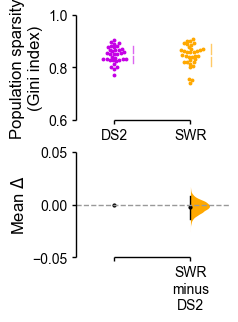

In [5]:
###################################################################################################
panel = '3c'
###################################################################################################
idata = sparsity_dict
size_scale = 2
#### determine columns and conditions to create pandas dataframe from data dictionary #################
innerkey = sbf.keys_to_list(idata)
outerkey = ['prepulse','pulse']
col_head = ['id','Event_Type','Pulse_Type','Data','Event_Pulse']
col_groups = {'noevent':'Baseline',
              'ds':'DS',
              'ds1':'DS1',
              'ds2':'DS2',
              'swr':'SWR',
             }
#### specify the contrasts for plotting and analyses, each row is a within-samples comparison #######
if panel == '3b':
    df_idx = [
                ['Baseline_pulse','DS_pulse','DS1_pulse','DS2_pulse','SWR_pulse'],
             ]
    contrast_ylim = (-0.2,0.05)
    contrast_maj_loc = 0.1

elif panel == '3c':
    df_idx = [
                ['DS2_pulse','SWR_pulse'],
             ]
    contrast_ylim = (-.05,0.05)
    contrast_maj_loc = 0.05
#### create a DABEST analysis object, specify that analyses are within-samples (paired='baseline') ####
analysis_of_long_df = dbh.generate_dabest_analysis(idata,
                                                   outerkey,
                                                   innerkey,
                                                   col_head,
                                                   col_groups,
                                                   df_idx,
                                                   paired='baseline',
                                                   x='Event_Pulse',
                                                   y='Data')
###########################################################################################################
my_color_palette = dbh.get_event_palette(df_idx)
fig,swarm_ax,contrast_ax = dbh.plot_dabest_swarm_contrast(analysis_of_long_df,
                                                          df_idx,
                                                          show_pairs=False,
                                                          diff_type='mean',
                                                          swlab='Population sparsity\n(Gini index)',
                                                          size_scale=2,
                                                          fwd=1.25,
                                                          fht=4,
                                                          pad=1.5,
                                                          lw=0.5,
                                                          swarm_ylim=(0.6,1),
                                                          contrast_ylim=contrast_ylim,
                                                          swarm_maj_loc=0.2,
                                                          contrast_maj_loc=contrast_maj_loc,
                                                          fscale=(5,6,7),
                                                          raw_marker_size=0.8,
                                                          my_color_palette=my_color_palette)
######################################################################################################################
swarm_ax,contrast_ax = dbh.adjust_dabest_labels(swarm_ax,contrast_ax,df_idx,max_char=8,str_indx=0,upper_case=True)
######################################################################################################################
plt.show()
######################################################################################################################

In [6]:
####################################################################################################
analysis_of_long_df.mean_diff.statistical_tests
####################################################################################################

,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,DS2_pulse,SWR_pulse,34,34,mean difference,baseline,-0.001972,95,-0.014181,0.008101,0.7276,0.82635,284.0,0.733147,0.343842


#### Run classifier to see if the spiking content during Dentate spikes differs from that in Sharp-wave ripples

In [7]:
from classifier import run_event_classification 

all_clf_dat =  run_event_classification(IFR_data,
                                        bsnm_list,
                                        event_list=['ds','swr'],
                                        cond_list = ['prepulse','pulse','postpulse'],
                                        clf_type_str = "LogReg",
                                        train_prop = 0.75,
                                        nprs = 100,
                                        match_train_number = True,
                                        binarize = True,
                                        verbose = False)

#### Plot classifier performance for epochs during dentate spikes versus sharp-wave ripples <br>and also for matched-epochs before (pre-event) and after (post-event) as in Figure 3d

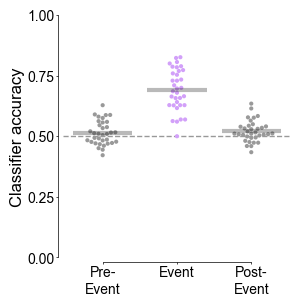

In [8]:
################################################################################
idata = all_clf_dat
################################################################################
innerkey = ['prepulse','pulse','postpulse']
outerkey = ['both']

col_head = ['id','sleep','event','Data','sleep_event']
col_groups = {'prepulse':'prepulse',
              'pulse':'pulse',
              'postpulse':'postpulse'
             }
################################################################################
df = dbh.dabest_long_df_2var(idata,innerkey,outerkey,col_groups,col_head)
################################################################################
figsize = (len(np.unique(df.sleep_event))*2.5,8)
chance_level = 0.5

fig,ax = cat_plot_clf(df,
                      palette=(gray2,LIGHTPURPLE,gray2,PURPLE),
                      hue_col='sleep_event',
                      legend=False,
                      msize=3,
                      figsize=figsize)

ax.axhline(chance_level,linewidth=1,linestyle='--',color=gray2)

## replace x-axis labels
label_list = [x for x in ['Pre-\nEvent', 'Event','Post-\nEvent'] ]
ax.set_xticklabels(label_list, minor=False)

plt.show()
################################################################################################

#### Generate population vector similarity data

#### Use this to generate example matrices in Figure 3e
set bsnm_indx = 16 (for the examples used in manuscript; or set to other value (between 0 and 33) to see matrices from other recording days)

/Dupret_Lab/analysis/smchugh_analysis/SF_analysis/Data_sharing/neuron_2024_repro/src/analysis.py:782: RuntimeWarning: invalid value encountered in divide
  dist = np.dot(A_mA,B_mB.T)/np.sqrt(np.dot(ssA[:,None],ssB[None]))


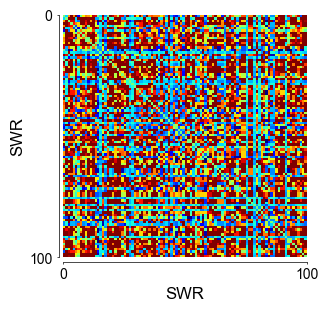

/Dupret_Lab/analysis/smchugh_analysis/SF_analysis/Data_sharing/neuron_2024_repro/src/analysis.py:782: RuntimeWarning: invalid value encountered in divide
  dist = np.dot(A_mA,B_mB.T)/np.sqrt(np.dot(ssA[:,None],ssB[None]))


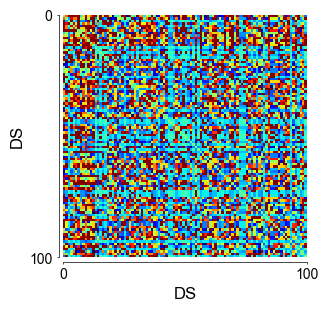

In [9]:
#########################################################################
bsnm_indx = 16 
event_pair_list = [['swr','swr'],['ds','ds']]
for event_1, event_2 in event_pair_list:
    #########################################################################
    sim_mat = an.get_single_similarity_matrix(IFR_data,
                                           bsnm_indx,
                                           event_1,
                                           event_2,
                                           max_bin=an.get_max_bin(event_1)
                                          )
    #########################################################################
    fig,ax = plot_single_similarity_matrix(sim_mat,
                                           event_1,
                                           event_2,
                                           cbar=False,
                                           fwd=8,
                                           fht=8,
                                           size_scale=2,
                                           vlim=(-0.3,0.3),
                                           cmap='jet',
                                           nprs=10,
                                           fscale=(5,6,8)
                                          )
    plt.show()
    ########################################################################

#### Generate data required for Figure 3F and Figure 3G

In [10]:
event_pair_list = [
                    ['noevent','noevent'],
                    ['swr','swr'],
                    ['ds','ds'],
                    ['ds1','ds1'],
                    ['ds2','ds2']
                  ]
PV_sim_dict = an.generate_pv_similarity_data(IFR_data,
                                              bsnm_list,
                                              event_pair_list,
                                              rand_subset = True,
                                              binarize = True,
                                              shuffle_list = [False,True],
                                              event_list=['ds','swr'],
                                              output_dat = 'mean',
                                              cond = 'pulse'
                                              )

/Dupret_Lab/analysis/smchugh_analysis/SF_analysis/Data_sharing/neuron_2024_repro/src/analysis.py:782: RuntimeWarning: invalid value encountered in divide
  dist = np.dot(A_mA,B_mB.T)/np.sqrt(np.dot(ssA[:,None],ssB[None]))


#### Compare Population vector similarity across baseline, SWR and DS (Figure 3f) <br> or for SWR versus DS1, DS2 (Figure 3g)

In [11]:
###################################################################################################
idata = PV_sim_dict['data']
figure_panel = '3f'
##################################################################################################
innerkey = ['noevent_noevent','swr_swr','ds_ds','ds1_ds1','ds2_ds2']
outerkey = []
col_head = ['id','ikey','Data','Cond_Event']
col_groups = {'noevent_noevent': 'BASE',
              'ds_ds':   'DS',
              'swr_swr': 'SWR',
              'ds1_ds1':   'DS1',
              'ds2_ds2': 'DS2',
             }

if figure_panel == '3f':
    df_idx = [
               ['BASE','SWR','DS'], 
             ]
    contrast_ylim = (-0.06,0.2)
    contrast_maj_loc = 0.1
    
elif figure_panel == '3g':
    df_idx = [
                ['SWR','DS1','DS2'],
             ]
    contrast_ylim = (-0.12,0.06) 
    contrast_maj_loc = 0.06

#### create a DABEST analysis object, specify that analyses are within-samples (paired='baseline') ####
analysis_of_long_df = dbh.generate_dabest_analysis(idata,
                                                   outerkey,
                                                   innerkey,
                                                   col_head,
                                                   col_groups,
                                                   df_idx,
                                                   paired='baseline',
                                                   x='Cond_Event',
                                                   y='Data')

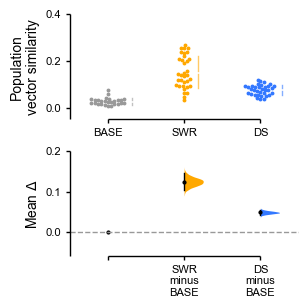

,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,BASE,SWR,34,34,mean difference,baseline,0.124022,95,0.103774,0.145397,0.0,1.164153e-10,0.0,5.409501e-13,-11.408337
1,BASE,DS,34,34,mean difference,baseline,0.048458,95,0.041820,0.055437,0.0,1.164153e-10,0.0,3.098121e-15,-13.772134


In [12]:
swarm_ylim = (-.05,.4)
swarm_maj_loc = 0.2
my_color_palette = dbh.get_event_palette(df_idx)
fig,swarm_ax,contrast_ax = dbh.plot_dabest_swarm_contrast(analysis_of_long_df,
                                                          df_idx,
                                                          swlab='Population\nvector similarity',
                                                          size_scale=2,
                                                          fwd=1.25,
                                                          fht=4,
                                                          pad=1.5,
                                                          lw=0.5,
                                                          swarm_ylim=swarm_ylim,
                                                          contrast_ylim=contrast_ylim,
                                                          swarm_maj_loc=swarm_maj_loc,
                                                          contrast_maj_loc=contrast_maj_loc,
                                                          fscale=(4,5,6),
                                                          raw_marker_size=0.8,
                                                          my_color_palette=my_color_palette)

swarm_ax,contrast_ax = dbh.adjust_dabest_labels(swarm_ax,contrast_ax,df_idx,max_char=8,str_indx=0,upper_case=True)
plt.show()
analysis_of_long_df.mean_diff.statistical_tests

In [ ]:
## load clustering data from disk
load_from_disk = True
###################################################################################
mpath = '/Dupret_Lab/analysis/smchugh_analysis'
output_path = '/SF_analysis/ClusterCoeff/' + day_type + '/' + group_type
###################################################################################
fname = 'clust_all_mice.npy'
full_path = mpath + output_path + '/' + fname
###################################################################################
if load_from_disk:
    all_mice_clust = np.load(full_path,allow_pickle=True).item()
###################################################################################

In [13]:
###################################################################################################
idata = all_mice_clust
figure_panel = '3f' #  could be '3f' or 'S4k'
###################################################################################################
innerkey = ['noevent','swr','ds','ds1','ds2']
outerkey = ['prepulse','pulse']
###################################################################################################
col_head = ['id','Event_Type','Sess_Type','Data','Group_sess']
col_groups = {'ds':'DS',
              'swr':'SWR',
              'noevent':'BASE',
              'ds1':'DS1',
              'ds2':'DS2',
             }
###################################################################################################
if figure_panel == '3f':
    df_idx = [
                ['BASE_pulse','SWR_pulse','DS_pulse'],
             ]
    contrast_ylim =(0,0.03)
    contrast_maj_loc = 0.015
###################################################################################################    
elif figure_panel == 'S4k':
    df_idx = [
                ['BASE_pulse','SWR_pulse','DS_pulse'],
             ]
    contrast_ylim =(-0.12,0.06)
    contrast_maj_loc = 0.06
###################################################################################################
analysis_of_long_df = generate_dabest_analysis(idata,
                                               outerkey,
                                               innerkey,
                                               col_head,
                                               col_groups,
                                               df_idx,
                                               paired='baseline',
                                               x='Group_sess',
                                               y='Data',
                                               id_col='id')
###################################################################################################

NameError: name 'all_mice_clust' is not defined

In [ ]:
swarm_ylim = (-0.05,0.2)
swarm_maj_loc = 0.1

fig,swarm_ax,contrast_ax = plot_dabest_swarm_contrast(analysis_of_long_df,
                                                       df_idx,
                                                       show_pairs=False,
                                                       diff_type='mean',
                                                       swlab='Clustering\ncoefficient',
                                                       size_scale=2,
                                                       fwd=1.25,
                                                       fht=4,
                                                       pad=1.5,
                                                       swarm_ylim=swarm_ylim,
                                                       contrast_ylim=contrast_ylim,
                                                       swarm_maj_loc=swarm_maj_loc,
                                                       contrast_maj_loc=contrast_maj_loc,
                                                       fscale=(5,6,7),
                                                       raw_marker_size=0.001,
                                                       jitter=8,
                                                       my_color_palette=[gray2,ORNG,BLUE])

swarm_ax,contrast_ax = adjust_dabest_labels(swarm_ax,contrast_ax,df_idx,max_char=8,str_indx=0,upper_case=True)
plt.show()

In [ ]:
analysis_of_long_df.mean_diff.statistical_tests

In [ ]:
analysis_of_long_df.cohens_d.statistical_tests

In [ ]:
###################################################################################################
idata = all_clf_dat

outerkey = ['ds','swr','both']
innerkey = ['prepulse','pulse','postpulse']

col_head = ['id','Event_Type','Sess_Type','Data','Group_sess']

col_groups = {'prepulse':'prepulse',
              'pulse':'pulse',
              'postpulse':'postpulse'
             }
####################################################################################################
df = sbf.dabest_long_df_2var(idata,innerkey,outerkey,col_groups,col_head)
####################################################################################################
df_idx = [
            ['prepulse_ds2','prepulse_swr'],
            ['pulse_ds2','pulse_swr'],
         ]

df_idx = [
            ['pulse_swr','pulse_ds'],
         ]

df_idx = [
            ['pulse_both','prepulse_both','postpulse_both'],
         ]
#####################################################################################################
paired = 'baseline'
analysis_of_long_df = db2.load(df,
                              x="Group_sess", 
                              y="Data",
                              idx=((df_idx)),
                              paired=paired,
                              id_col="id"
                              )
######################################################################################################
show_pairs = False
######################################################################################################
fwd,fht = 1.0*len(sbf.flatten(df_idx)),4
diff_type = 'mean'
swlab = 'Classifier\naccuracy'
if diff_type == 'mean':
    eslab = 'Mean ' + r'$\Delta$'
    stats_test = analysis_of_long_df.mean_diff.statistical_tests
elif diff_type == 'median':
    eslab = 'Median ' + r'$\Delta$'
    stats_test = analysis_of_long_df.median_diff.statistical_tests
#######################################################################################################
my_color_palette = [LIGHTBLUE,LIGHTORNG2,BLUE,ORNG,PURPLE,LIGHTORNG2,ORNG]
my_color_palette = [BLUE,ORNG,PURPLE,LIGHTORNG2,ORNG]
#######################################################################################################
size_scale = 2
swarm_ylim = (0,1)
contrast_ylim =(-.3,.1)
swarm_maj_loc = .5
contrast_maj_loc = .1
font_scale = (6,7,8)
pad = 1.5
lw = 0.5
bw_method = .5 #sbf.calc_mean_bw(idata,innerkey,outerkey)
########################################################################################################
fig,swarm_ax,contrast_ax = sbf.smdabest_plot(analysis_of_long_df,
                                             diff_type=diff_type,
                                             figsize=[fwd,fht],
                                             size_scale=size_scale,
                                             swarm_ylim=swarm_ylim,
                                             contrast_ylim=contrast_ylim,
                                             my_color_palette=my_color_palette,
                                             swlab=swlab,
                                             eslab=eslab,
                                             fs=font_scale,
                                             show_pairs=show_pairs,
                                             maj_loc=[swarm_maj_loc,contrast_maj_loc],
                                             bw_method=bw_method
                                            )
########################################################################################################
sw_xtlabs,con_xtlabs = sbf.generate_dabest_xtlabs(df_idx,max_char=5,str_indx=0)
swarm_ax.set_xticklabels(sw_xtlabs)
contrast_ax.set_xticklabels(con_xtlabs)

swarm_ax.axhline(0.5,linestyle='--',color=gray2,linewidth=lw)
########################################################################################################
plt.show()
########################################################################################################
analysis_of_long_df.mean_diff.statistical_tests
########################################################################################################

In [ ]:
def generate_raster_from_IFR(idata,axoff=False,fwd=20,fht=10):
    '''
    
    '''
    from matplotlib import cm
    ######################################################################################
    lw=.5
    alpha=1.0
    sp_tick_height=.008
    rast_w=2.5
    v_ofs=0.01
    vert_offset = sp_tick_height + v_ofs
    rr,cc = 1,1
    sp_col = 'k'
    #######################################################################################
    fig, ax = plt.subplots(rr,cc,
                           figsize=sbf.cm2inch(fwd,fht),
                           gridspec_kw={'wspace':0,'hspace':0},
                           sharex=True)
    #######################################################################################
    
    n_cells = idata.shape[0]
    n_bins = idata.shape[1]
    
    all_ymin = 1
    clu_count = 0
    for clu_ in np.arange(n_cells):
        
        clu_offset = clu_count * vert_offset
        clu_count += 1
        
        ymin = (.98-sp_tick_height) - clu_offset
        #print(np.around(ymin,3))
        ymax = ymin + sp_tick_height
        
        if ymin < 0:
            print('ymin is off the screen for {0:}'.format(clu_))
        
        temp_dat = idata[clu_,:]
        
        #x_coords = np.array([x+np.random.uniform(-.2,.2) for x in np.nonzero(temp_dat)])
        x_coords = np.array([x for x in np.nonzero(temp_dat)])
        
        for indx,sp_ in enumerate(*x_coords):
            #print(sp_)
            ax.axvline(sp_,
                       ymin=ymin,
                       ymax=ymax,
                       linewidth=lw*rast_w,
                       color=sp_col)

    #all_ymin = np.nanmin([all_ymin,ymin])
    
    ax.set_xlim(0,idata.shape[1])
    #ax.set_ylim(all_ymin*2,1.2)
    if axoff:
        ax.set_axis_off()

    return fig,ax

In [ ]:
################################################################################
idata = all_mice_clust
################################################################################
innerkey = ['ds','swr']
outerkey = ['pulse']

col_head = ['id','sleep','event','Data','sleep_event']
col_groups = {'ds':'ds',
              'swr':'swr'
             }
################################################################################
df = sbf.dabest_long_df_2var(idata,innerkey,outerkey,col_groups,col_head)
################################################################################
figsize = (len(np.unique(df.sleep_event))*1.25,4)
fig,ax = cat_plot_clf(df,palette=(gray2,LIGHTPURPLE,ORNG,PURPLE),msize=1.5,ylim=(0,1),ytick_width=0.25,figsize=figsize)
ax.axhline(0.5,linewidth=0.5,linestyle='--',color=gray2)

## replace x-axis labels
lab_list = [x for x in ['ds', 'swr'] ]
ax.set_xticklabels(lab_list, minor=False)

plt.show()
################################################################################################

In [ ]:
## PCA

import smPcaFunctions3 as spf

thrs = 0.9
norm = True
min_comp = 2

iDict = new_IFR_dict
event_list = ['ds1','ds2','swr']
cond = 'pulse'

pc_dict = {}
for key,val in iDict.items():
    print(key,len(val))
    tempdat = []
    for mindx,mouse in enumerate(new_mouseID):
        max_bin = find_max_bin_1d(iDict,
                                  mindx,
                                  event_list,
                                  cond=cond)
        idata = val[mindx][cond]
        idata = select_random_subset(idata,max_bin=max_bin,axis=1)
        pc_var = spf.calc_pca_single_matrix(idata,thrs=thrs,norm=norm,min_comp=min_comp)
        tempdat.append(pc_var)
        print(mindx,mouse,idata.shape,pc_var)
    pc_dict[key] = np.array(tempdat)

In [ ]:
key1 = 'ds2'
key2 = 'swr'

diff_score = [(a-b)/(abs(a)+abs(b)) for (a,b) in zip(pc_dict[key1],pc_dict[key2])]

diff_score = np.array(diff_score)

In [ ]:
cond_1 = key1
cond_2 = key2
data_1 = pc_dict[cond_1]
data_2 = pc_dict[cond_2]
print(data_1.mean(),data_2.mean())

tval,pval = sbf.smc_ttest([data_1,data_2],cond_list=[cond_1,cond_2],paired=True)

wilc,wilc_pval = stats.wilcoxon(data_1,data_2)

print('U={0:.1f}; p={1:.3f}'.format(wilc,wilc_pval))

In [ ]:
stats.ttest_1samp(diff_score,0)

In [ ]:
###################################################################################################
idata = pc_dict

innerkey = ['noevent','swr','ds','ds1','ds2']

col_head = ['id','ikey','Data','Group_sess']
col_groups = {
              'noevent': 'BASE',
              'ds':   'DS',
              'ds1':  'DS1',
              'ds2':  'DS2',
              'swr': 'SWR',
             }
####################################################################################################
df = sbf.dabest_long_df_1var(idata,innerkey,col_groups,col_head)
####################################################################################################
df_idx = [
            ['BASE','DS','SWR','DS_SWR','DS_BASE','SWR_BASE'],
         ]

df_idx = [
            ['BASE','DS','DS1','DS2','SWR'],
         ]

df_idx = [
            ['BASE','SWR','DS'],
         ]
'''df_idx = [
            ['DS1','DS2'],
         ]'''

'''df_idx = [
            ['SWR','DS1','DS2'],
         ]'''
#####################################################################################################
paired = 'baseline'
analysis_of_long_df = db2.load(df,
                              x="Group_sess", 
                              y="Data",
                              idx=((df_idx)),
                              paired=paired,
                              id_col="id"
                              )

######################################################################################################
show_pairs = False
######################################################################################################
fwd,fht = 1.25*len(sbf.flatten(df_idx)),4

fwd,fht = 2.5,3.5
diff_type = 'mean'
swlab = 'Dimensionality'
if diff_type == 'mean':
    eslab = 'Mean ' + r'$\Delta$'
    stats_test = analysis_of_long_df.mean_diff.statistical_tests
elif diff_type == 'median':
    eslab = 'Median ' + r'$\Delta$'
    stats_test = analysis_of_long_df.median_diff.statistical_tests
#######################################################################################################
my_color_palette = get_event_palette(df_idx)
#######################################################################################################
size_scale = 2
swarm_ylim = (0,1)#None#(-.05,.6)
contrast_ylim = (-.1,.2)
swarm_maj_loc = .5
contrast_maj_loc = .1
font_scale = (6,7,8)
pad = 1.5
bw_method = .5 #sbf.calc_mean_bw(idata,innerkey,outerkey)
########################################################################################################
fig,swarm_ax,contrast_ax = sbf.smdabest_plot(analysis_of_long_df,
                                             diff_type=diff_type,
                                             figsize=[fwd,fht],
                                             size_scale=size_scale,
                                             swarm_ylim=swarm_ylim,
                                             contrast_ylim=contrast_ylim,
                                             my_color_palette=my_color_palette,
                                             swlab=swlab,
                                             eslab=eslab,
                                             fs=font_scale,
                                             show_pairs=show_pairs,
                                             maj_loc=[swarm_maj_loc,contrast_maj_loc],
                                             bw_method=bw_method
                                            )
########################################################################################################
sw_xtlabs,con_xtlabs = generate_dabest_xtlabs(df_idx)
swarm_ax.set_xticklabels(sw_xtlabs)
contrast_ax.set_xticklabels(con_xtlabs)
########################################################################################################
plt.show()
########################################################################################################
analysis_of_long_df.mean_diff.statistical_tests
########################################################################################################

In [ ]:
def pca_on_dict(iDict,new_mouseID,cond='pulse',event_list=['ds','swr'],thrs=0.8,norm=True,min_comp=2):
    '''
    
    '''
    pc_dict = {}
    for key,val in iDict.items():
        #print(key,len(val))
        tempdat = []
        for mindx,mouse in enumerate(new_mouseID):
            max_bin = find_max_bin_1d(iDict,
                                      mindx,
                                      event_list,
                                      cond=cond)
            #print(mouse,max_bin)
            idata = val[mindx][cond]
            idata = select_random_subset(idata,max_bin=max_bin,axis=1)
            pc_var = spf.calc_pca_single_matrix(idata,thrs=thrs,norm=norm,min_comp=min_comp)
            tempdat.append(pc_var)
            #print(idata.shape,pc_var)
        pc_dict[key] = np.array(tempdat)
        
    return pc_dict

In [ ]:
cell_count = []
for mindx,mouse in enumerate(new_mouseID):
    cell_count.append(new_IFR_dict['noevent'][mindx]['pulse'].shape[0])
    print(new_IFR_dict['noevent'][mindx]['pulse'].shape)
    
print(np.nanmean(cell_count),sbf.stdErr(cell_count))

In [ ]:
## Produce plot for continuous variance explained PCA

thrs_vals = np.arange(0.70,0.96,0.01)
norm = True
parametric = False
paired = True
alternative = 'greater' #'two-sided'

iDict = new_IFR_dict#new_IFR_dict

event_list=['ds2','swr']

pval_list = []
for thrs in thrs_vals:
    pc_dict = pca_on_dict(iDict,new_mouseID,cond='pulse',event_list=event_list,thrs=thrs,norm=norm,min_comp=2)
    
    cond_1 = event_list[0]
    cond_2 = event_list[1]
    data_1 = pc_dict[cond_1]
    data_2 = pc_dict[cond_2]

    if parametric:
        tval,pval = sbf.smc_ttest([data_1,data_2],cond_list=[cond_1,cond_2],paired=paired)
    else:
        tval,pval = stats.wilcoxon(data_1,data_2,alternative=alternative)
    pval_list.append(pval)

pval_list = np.array(pval_list)

In [ ]:
print(pval_list.shape,thrs_vals.shape)

In [ ]:
sns.reset_orig()

fwd,fht = 4,4
xlim = (0.7,0.95)
ylim = (0,.1)
xtick_width = 0.05
ytick_width = 0.05
lw = 0.5

xlab = 'Variance explained (%)'
ylab = 'Probability'

fig,ax = plt.subplots(1,1,figsize=sbf.cm2inch(fwd,fht))

ax.plot(thrs_vals,pval_list,linewidth=lw,color='k')
ax.set_ylim(ylim)
ax.xaxis.set_major_locator(Ticker.MultipleLocator(xtick_width))
ax.yaxis.set_major_locator(Ticker.MultipleLocator(ytick_width))

ax.axhline(0.05,linewidth=lw,linestyle='--',color=BLUE)

ax = sbf.set_axis_bounds(ax,xlim=xlim,ylim=ylim)
ax = sbf.adjust_plot_pub(ax,
                         xt_fmt='.2f',
                         yt_fmt='.2f',
                         xlab=xlab,
                         ylab=ylab,
                         grid=False,
                         fscale=(6,7))
plt.show()

In [ ]:
######Save the figure###########################################################################
savefig = True
fsize_str = 'x'.join((str(fwd),str(fht)))
event_str = '_'.join(sw_xtlabs)
opath = '/Dupret_Lab/analysis/smchugh_analysis/figures/PCA/' + group_type + '/'
ftitle = '_'.join(('PCA_pvals_75_99_one_tailed',
                   event_str,
                   cond,
                   group_type,
                   fsize_str
                  ))
################################################################################################
if savefig:
    sbf.savefig(fig,opath,ftitle,ext='.svg')
################################################################################################

In [ ]:
thrs_vals = np.arange(0,0.96,0.01)
norm = False

iDict = new_IFR_dict # bool_IFR_dict #new_IFR_dict

event_list=['ds1','ds2','swr']

n_thrs_vals = len(thrs_vals)
n_mice = 34
n_events = len(event_list)

output_matrix = np.zeros((n_thrs_vals,n_mice,n_events))
for thrs_indx,thrs in enumerate(thrs_vals):
    pc_dict = pca_on_dict(iDict,new_mouseID,cond='pulse',event_list=event_list,thrs=thrs,norm=norm,min_comp=2)
    
    for ev_indx,event in enumerate(event_list):
        output_matrix[thrs_indx,:,ev_indx] = np.array(pc_dict[event])
    
output_matrix.shape

In [ ]:
event_palette = {'noevent':gray2, 'ds1':GREEN, 'ds2':PURPLE, 'swr':ORNG}

fwd,fht = 4,4
xlim = (0,25)
#xlim = (0.2,1)
ylim = (.7,1.0)
xtick_width = 5
ytick_width = .1
lw = 0.5
marker = None
markersize = 1

xlab = 'Number of components'
ylab = 'Variance explained (%)'

fig,ax = plt.subplots(1,1,figsize=sbf.cm2inch(fwd,fht))
for ev_indx,event in enumerate(event_list):
    idata = np.nanmean(output_matrix[:,:,ev_indx],axis=-1)
    xpts = idata
    ypts = thrs_vals
    pos_err,neg_err = sbf.calc_err_bars(output_matrix[:,:,ev_indx],axis=1,savgol=False,npts=1)
    ax.plot(xpts,ypts,linewidth=lw,color=event_palette[event],marker=marker,markersize=markersize)
    
ax.set_ylim(ylim)
ax.set_xlim(xlim)
ax.xaxis.set_major_locator(Ticker.MultipleLocator(xtick_width))
ax.yaxis.set_major_locator(Ticker.MultipleLocator(ytick_width))

ax = sbf.set_axis_bounds(ax,xlim=xlim,ylim=ylim)
ax = sbf.adjust_plot_pub(ax,
                         xt_fmt='.0f',
                         yt_fmt='.1f',
                         xlab=xlab,
                         ylab=ylab,
                         grid=False,
                         fscale=(6,7))
plt.show()